### 불용어, 단어 빈도, 워드클라우드
- 자주 나온다 -> 중요하다, 개수를 세어야 한다 -> 그 문서의 주제
- 불용어 처리 전 vs 후 비교
- 워드클라우드로 핵심 단어를 한눈에 보기

- 어떤 문서가 무엇을 다루는 문서인지 -> 자주 나오는 단어라는 가설에서 출발
- 모든 문서에 흔한 단어는 의미가 없는 단어!
- 예)
    - 뉴스 기사에 흔한 단어 : 기자, 뉴스 등 -> 제거해야

### 1. 사전 준비

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

from kiwipiepy import Kiwi
kiwi = Kiwi()
df = pd.read_csv("../data/11-1_뉴스정제.csv")

In [3]:
# 명사 추출 함수 만들기

def extract_nouns(text):
    nouns = []
    result = kiwi.tokenize(text)

    for token in result:
        if token.tag.startswith("N"):
            nouns.append(token.form)

    nouns_filtered = []

    for noun in nouns:
        if len(noun) > 1:
            nouns_filtered.append(noun)

    return nouns_filtered

In [7]:
# 모든 기사의 명사를 한 곳에 모아서 빈도 세어보기
all_nouns = []
df['명사'] = df['정제본문'].apply(extract_nouns)
df[['정제본문', '명사']].head(3)

,정제본문,명사
0,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,"[서울, 연합뉴스, 현대백화점그룹, 광주광역시, 서울, 여의도, 현대, 서울, 문화..."
1,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...,"[전주, 뉴시스, 김얼, 기자, 이스타항공, 자금, 배임, 횡령, 전주, 교도소, ..."
2,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...,"[NH농협은행, 올해, 농협, 금융, 출범, 주년, 이달, 주년, 기념, 주화, 대..."


In [8]:
for doc_noun in df['명사']:
    all_nouns.extend(doc_noun)

print(len(all_nouns))

179518


In [10]:
from collections import Counter
count_result = Counter(all_nouns)

count_result.most_common(10)    # 가장 자주 나온 단어 상위 10개

[('기업', 999),
 ('서비스', 920),
 ('사업', 851),
 ('기술', 777),
 ('제공', 748),
 ('시장', 687),
 ('개발', 657),
 ('국내', 599),
 ('투자', 592),
 ('가능', 557)]

In [11]:
# 불용어
# 의미 없는 단어라고 간주할 때 -> 그 단어를 삭제

stopwords = ['기자', '연합뉴스', '뉴스', '기업']

filtered_all_nouns = []

for noun in all_nouns:
    if noun not in stopwords:   # 불용어 리스트에 없는 단어일 경우에만
        filtered_all_nouns.append(noun)

In [ ]:
count_after = Counter(filtered_all_nouns)
count_after.most_common(20)

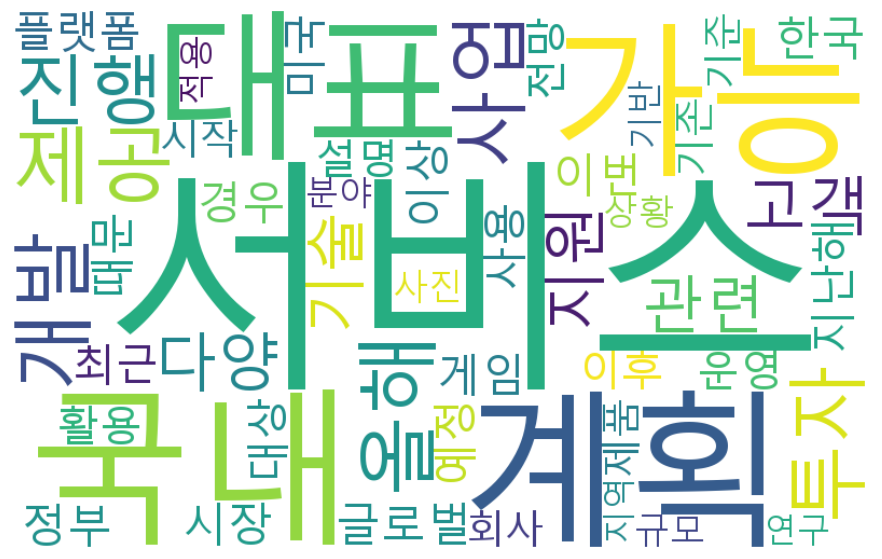

In [13]:
# 시각화 - 워드클라우드 -> 자주 나온 단어는 크게 표시
from wordcloud import WordCloud

# 명사 리스트를 하나의 문자열로 합치기
text = ' '.join(filtered_all_nouns)

# 한글 폰트 경로
font_path = r"C:\Windows\Fonts\malgun.ttf"

# 워드클라우드 객체 만들기
wordcloud = WordCloud(
    font_path=font_path,
    width=800,
    height=500,
    background_color='white',
    max_words=50
).generate(text)

# 화면에 출력
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

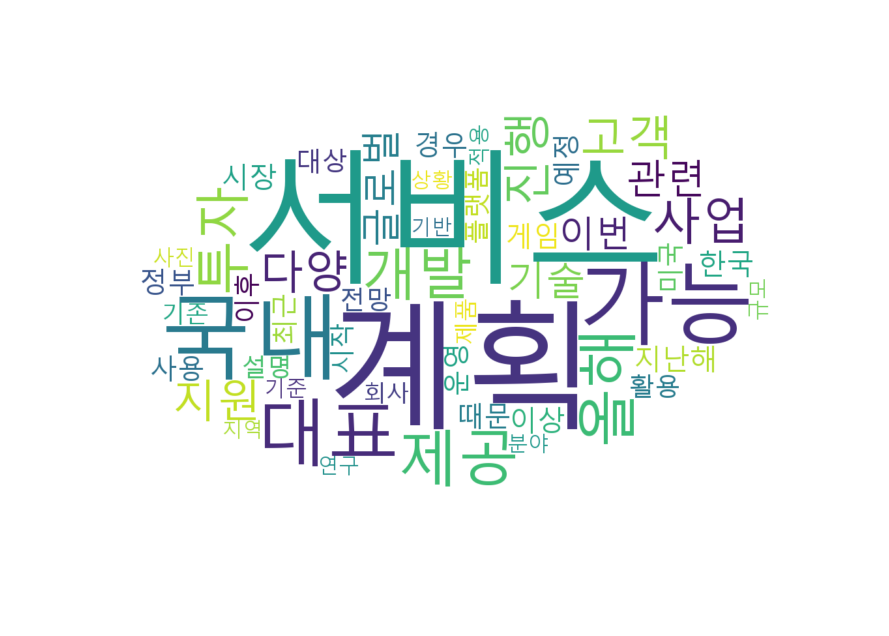

In [19]:
import numpy as np
from PIL import Image

# 명사 리스트 → 하나의 문자열
text = ' '.join(filtered_all_nouns)

# 모양 이미지 파일 경로
mask_image = np.array(Image.open('../data/cloud.png'))

wordcloud = WordCloud(
    font_path=r"C:\Windows\Fonts\malgun.ttf",
    width=800,
    height=500,
    background_color='white',
    mask=mask_image,       # 이미지 모양 적용
    max_words=50,
    colormap='viridis'     # 단어 색상 분위기
).generate(text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

#### 실전 실습 - 제주비짓 데이터로 워드클라우드?

In [20]:
jeju = pd.read_csv("../data/11-1_visitjeju_reviews.csv", encoding="cp949")
jeju.head()

,리뷰내용,추천수
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,159
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...",132
2,메밀꽃 지평선과 하늘입니다,57
3,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,29
4,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,29


In [21]:
jeju_clean = jeju.dropna(subset="리뷰내용")

In [22]:
jeju_clean.columns

Index(['리뷰내용', '추천수'], dtype='str')

In [27]:
all_nouns = []
jeju_clean['명사'] = jeju_clean['리뷰내용'].apply(extract_nouns)

for noun in jeju_clean['명사']:
    all_nouns.extend(noun)

In [30]:
count_result = Counter(all_nouns)

count_result.most_common(25)    # 가장 자주 나온 단어 상위 10개

[('제주', 1897),
 ('여행', 1021),
 ('제주도', 1005),
 ('바다', 537),
 ('사진', 512),
 ('시간', 309),
 ('가족', 302),
 ('한라산', 272),
 ('방문', 270),
 ('겨울', 270),
 ('추천', 255),
 ('풍경', 253),
 ('힐링', 242),
 ('추억', 240),
 ('친구', 237),
 ('생각', 236),
 ('마음', 234),
 ('자연', 232),
 ('아이', 222),
 ('우도', 203),
 ('사람', 202),
 ('카페', 194),
 ('행복', 191),
 ('해변', 189),
 ('우리', 181)]

In [31]:
stopwords = ['제주', '제주도']

filtered_all_nouns = []

for noun in all_nouns:
    if noun not in stopwords:   # 불용어 리스트에 없는 단어일 경우에만
        filtered_all_nouns.append(noun)

In [33]:
count_after = Counter(filtered_all_nouns)

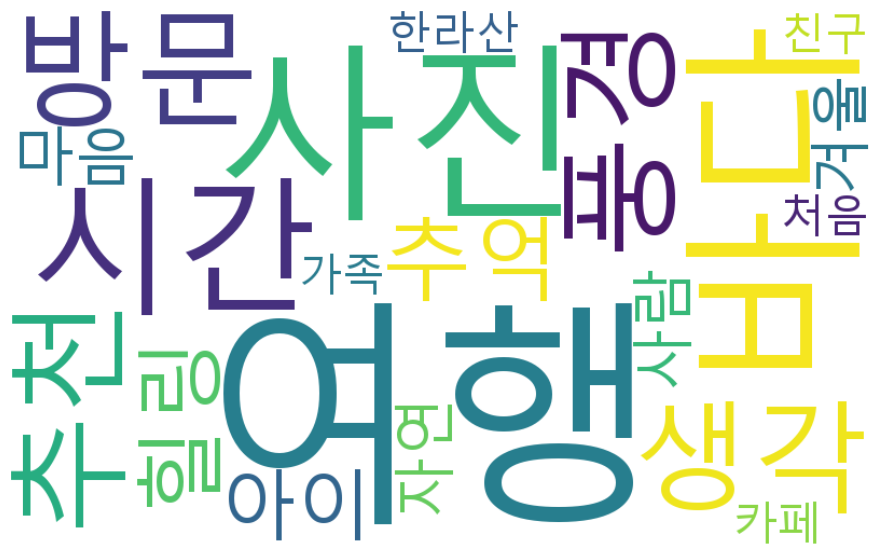

In [38]:
# 명사 리스트를 하나의 문자열로 합치기
text = ' '.join(filtered_all_nouns)

# 한글 폰트 경로
font_path = r"C:\Windows\Fonts\malgun.ttf"

# 워드클라우드 객체 만들기
wordcloud = WordCloud(
    font_path=font_path,
    width=800,
    height=500,
    background_color='white',
    max_words=20
).generate(text)

# 화면에 출력
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

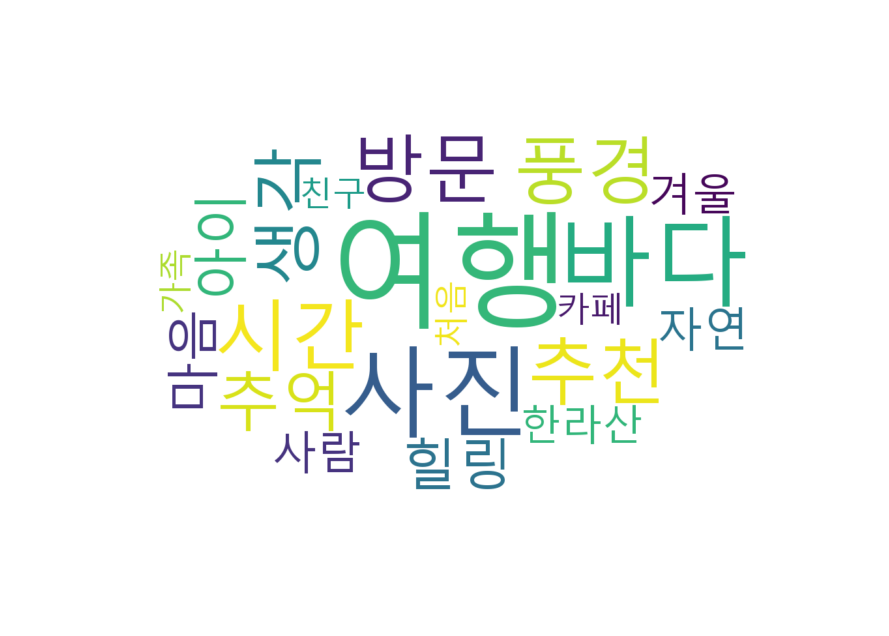

In [46]:
from matplotlib import font_manager

# 명사 리스트 → 하나의 문자열
text = ' '.join(filtered_all_nouns)
font_path = r"C:\Windows\Fonts\malgun.ttf"

# 구름 모양 안에 단어를 배치
mask_image = np.array(Image.open('../data/cloud.png'))

# 제주 바다를 떠올리는 색상 팔레트
def jeju_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    colors = ['#0077B6', '#0096C7', '#00B4D8', '#007F86', '#023E8A']
    return random_state.choice(colors)

wordcloud = WordCloud(
    font_path=font_path,
    width=1200,
    height=800,
    background_color='#F4FBFC',
    mask=mask_image,
    max_words=30,
    contour_width=2,
    contour_color='#0096C7',
    color_func=jeju_color_func,
    random_state=42
).generate(text)

title_font = font_manager.FontProperties(fname=font_path, size=20)
plt.figure(figsize=(12, 8), facecolor='#F4FBFC')
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('제주 관광 리뷰 핵심 단어', fontproperties=title_font, color='#023E8A', pad=18)
plt.axis('off')
plt.tight_layout()
plt.savefig('jeju_review_wordcloud.png', dpi=300, bbox_inches='tight', facecolor='#F4FBFC')
plt.show()

In [47]:
jeju_clean['해시태그'] = jeju_clean['리뷰내용'].str.findall(
    r'#([가-힣]+)'
)

jeju_clean[['리뷰내용', '해시태그']]

,리뷰내용,해시태그
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,"[제주도여행, 성공적, 제주추억공유캠페인, 추억이새록새록]"
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...",[]
2,메밀꽃 지평선과 하늘입니다,[]
3,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,"[제주소녀, 엄샤, 제주도민, 도민추천, 인생샷, 명소, 인생샷명소, 해바라기, 꽃밭]"
4,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,"[제주소녀, 엄샤, 도민추천, 먹이주기체험, 양떼목장, 애월읍, 체험학습, 육아]"
...,...,...
5912,제주를 사랑하시는 저의 아버지는 겨울왕국이 있을 것처럼 눈이 소복하게 쌓인 한라산을...,[]
5913,중문 놀러왔다가 들렸어요~ 체험 할 거리도 많고 사진도 많이 찍을 수 있어서 좋았어...,[]
5914,#이호테우#이호테우말등대제주도여행 마지막 날 이호테우에서 아쉬움을 달래본다.,"[이호테우, 이호테우말등대제주도여행]"
5915,홀로 여행을 떠나 새로운각오을 다지고 왔어요.,[]


In [52]:
all_nouns = []
jeju_clean['해시태그명사'] = jeju_clean['해시태그'].apply(
      lambda tags: extract_nouns(' '.join(tags))
  )

for noun in jeju_clean['해시태그명사']:
    all_nouns.extend(noun)

count_result = Counter(all_nouns)

count_result.most_common(25)    # 가장 자주 나온 단어 상위 10개

[('제주', 1061),
 ('여행', 701),
 ('제주도', 564),
 ('바다', 250),
 ('우도', 172),
 ('가을', 119),
 ('한라산', 94),
 ('오름', 86),
 ('맛집', 85),
 ('겨울', 82),
 ('여름', 81),
 ('성산', 71),
 ('가족', 69),
 ('해변', 67),
 ('해수욕장', 66),
 ('일출봉', 66),
 ('힐링', 63),
 ('먹거리', 57),
 ('사진', 53),
 ('해안', 46),
 ('카멜리아힐', 45),
 ('카페', 41),
 ('사려니숲', 41),
 ('친구', 41),
 ('서귀포', 40)]

In [57]:
all_hashtags = jeju_clean['해시태그'].explode().dropna().tolist()
count_result = Counter(all_hashtags)

count_result.most_common(25)

[('제주도', 320),
 ('제주', 318),
 ('제주여행', 190),
 ('바다', 127),
 ('우도', 90),
 ('제주도여행', 82),
 ('여행', 70),
 ('여름', 68),
 ('성산일출봉', 56),
 ('제주가을', 51),
 ('가족여행', 51),
 ('먹거리', 49),
 ('한라산', 49),
 ('비짓제주', 47),
 ('카멜리아힐', 45),
 ('사려니숲', 44),
 ('힐링', 39),
 ('제주바다', 36),
 ('사려니숲길', 30),
 ('산과오름', 28),
 ('사려니숲에코힐링체험', 26),
 ('산굼부리', 25),
 ('인생샷', 24),
 ('올레길', 23),
 ('섭지코지', 23)]

In [58]:
stopwords = ['제주', '제주도', '제주여행', '제주도여행', '비짓제주']

filtered_all_nouns = []

for noun in all_hashtags:
    if noun not in stopwords:   # 불용어 리스트에 없는 단어일 경우에만
        filtered_all_nouns.append(noun)



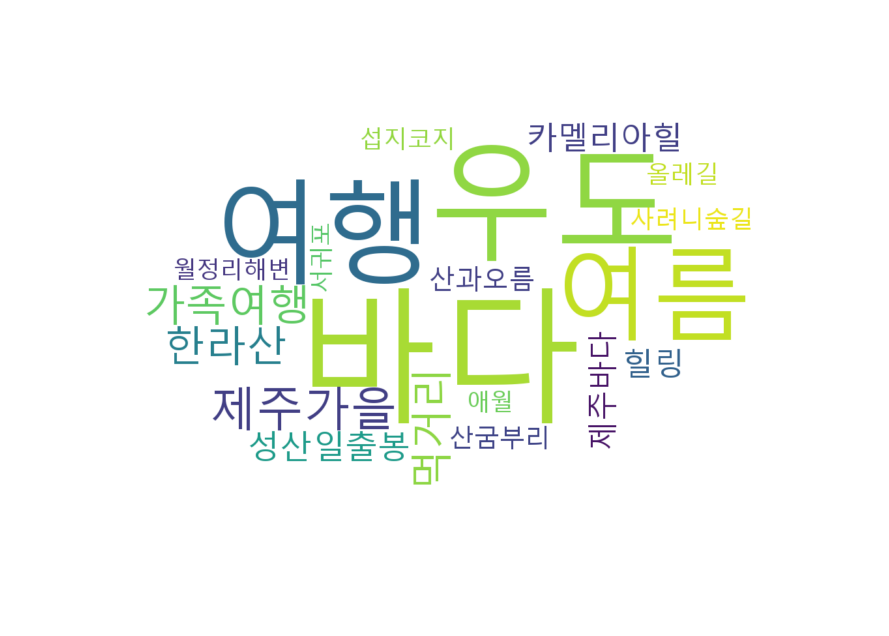

In [60]:
# 명사 리스트 → 하나의 문자열
text = ' '.join(filtered_all_nouns)

# 모양 이미지 파일 경로
mask_image = np.array(Image.open('../data/cloud.png'))

wordcloud = WordCloud(
    font_path=r"C:\Windows\Fonts\malgun.ttf",
    width=800,
    height=500,
    background_color='white',
    mask=mask_image,       # 이미지 모양 적용
    max_words=20,
    colormap='viridis'     # 단어 색상 분위기
).generate(text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()